# 🛒 How Dirty Data Cost a Retailer R7,129,010.66 in Phantom Revenue
## A Data Cleaning Case Study — Retail / E-Commerce Transactions

---
> **The Problem:** A retail business pulls its annual revenue report and sees **R7,129,010.66**. The finance team is pleased. But the data hasn't been cleaned. The real number is **R4,035,304.33**. That's a **R3,093,706.33 overstatement - a 76.7% error**

This notebook walks through exactly how that happens, and how to fix it.
<a id="0"></a> <br>
### What We'll Cover
- Load the raw (dirty) dataset
- Initial Data Inspection
- Clean the data step by step
- Compare revenue before and after
- Visualise the business impact

---
**Dataset:** 1,000 simulated retail transactions | FY 2024 | 10 product SKUs | 5 regions

## Setup — Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:,.2f}'.format) #This makes financial or statistical data much easier to read

# Chart style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BLUE = '#1F4E79'
RED = '#C00000'
GREEN = '#1E6B3C'
ORANGE = '#E07000'
LIGHT_BLUE = '#BDD7EE'
LIGHT_RED = '#FFC7CE'
LIGHT_GREEN = '#C6EFCE'


## 1. Load the Raw Data

We load everything as strings first — this is intentional. If we let pandas infer types on dirty data, it will silently fail on mixed-format columns (like prices with `R` signs or dates in different formats), and we'll lose visibility of the issues.

In [29]:
# Load raw data — dtype=str preserves all values exactly as they appear
raw = pd.read_csv('dirty_data_zar.csv', dtype=str)

print(f'Rows loaded: {len(raw):,}')
print(f'Columns: {list(raw.columns)}')
print(f'\nShape: {raw.shape}')

Rows loaded: 1,050
Columns: ['Transaction_ID', 'Date', 'Customer_ID', 'Product_SKU', 'Product_Name', 'Category', 'Region', 'Channel', 'Payment_Method', 'Quantity', 'Unit_Price', 'Discount_Rate', 'Revenue']

Shape: (1050, 13)


In [30]:
# First look at the data
raw.head(10)

,Transaction_ID,Date,Customer_ID,Product_SKU,Product_Name,Category,Region,Channel,Payment_Method,Quantity,Unit_Price,Discount_Rate,Revenue
0,TXN-00353,2024-02-14,CUST-1767,SKU-005,Backpack,Accessories,West,Marketplace,Bank Transfer,1,1099.0,0.0,1099.0
1,TXN-00690,2024-02-22,CUST-1391,SKU-004,Coffee Maker,Kitchen,North,Marketplace,Credit Card,2,2999.0,NaN,5698.09
2,TXN-00486,2024-07-22,CUST-2928,SKU-002,Running Shoes,Footwear,West,In-Store,Credit Card,3,1799.0,0.2,4317.6
3,TXN-00389,2024-05-20,CUST-1920,SKU-004,Coffee Maker,Kitchen,Online,In-Store,PayPal,3,2999.0,0.0,8997.0
4,TXN-00032,2024-02-08,CUST-2815,SKU-008,Protein Powder,Health,Online,Website,Credit Card,2,599.0,0.2,958.34
5,TXN-00443,2024-06-10,CUST-4793,SKU-005,Backpack,Accessories,West,In-Store,Debit Card,3,1099.0,0.2,2637.6
6,TXN-00199,2024-05-26,CUST-1314,SKU-001,Wireless Earbuds,Electronics,North,Marketplace,Bank Transfer,1,1299.0,0.0,1299.0
7,TXN-00426,2024-09-11,CUST-4903,SKU-003,Yoga Mat,Sports,East,In-Store,PayPal,1,649.0,0.0,649.0
8,TXN-00108,2024-10-28,CUST-2756,SKU-008,Protein Powder,Health,East,Website,Credit Card,4,599.0,0.0,2396.0
9,TXN-00715,2024-11-01,CUST-1634,SKU-010,Laptop Stand,Electronics,East,Website,PayPal,4,749.0,0.15,2546.66


## 2. Initial Data Inspection

Before cleaning anything, we audit the dataset systematically. The goal is to **quantify** every issue — not just note that problems exist, but understand how many rows are affected and what the business impact could be.

In [31]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Transaction_ID  1050 non-null   object
 1   Date            1050 non-null   object
 2   Customer_ID     1030 non-null   object
 3   Product_SKU     1050 non-null   object
 4   Product_Name    1050 non-null   object
 5   Category        1050 non-null   object
 6   Region          1030 non-null   object
 7   Channel         1050 non-null   object
 8   Payment_Method  1030 non-null   object
 9   Quantity        1050 non-null   object
 10  Unit_Price      1050 non-null   object
 11  Discount_Rate   1030 non-null   object
 12  Revenue         1050 non-null   object
dtypes: object(13)
memory usage: 106.8+ KB


In [32]:
print('=== MISSING VALUES ===')
missing = raw.isna().sum()
missing_pct = (missing / len(raw) * 100).round(1)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0])

print(f'\n=== DUPLICATE TRANSACTION IDs ===')
dup_count = raw['Transaction_ID'].duplicated().sum()
print(f'Duplicate rows: {dup_count}')

print(f'\n=== UNIQUE VALUES IN REGION ===')
num_regions = raw['Region'].nunique(dropna=True)
print(f'Number of unique regions: {num_regions}')
print(sorted(raw['Region'].dropna().unique()))

=== MISSING VALUES ===
                Missing Count  Missing %
Customer_ID                20       1.90
Region                     20       1.90
Payment_Method             20       1.90
Discount_Rate              20       1.90

=== DUPLICATE TRANSACTION IDs ===
Duplicate rows: 50

=== UNIQUE VALUES IN REGION ===
Number of unique regions: 22
['EAST', 'East', 'Est', 'N.', 'NORTH', 'North', 'Nrth', 'ONLINE', 'On-Line', 'Online', 'S.', 'SOUTH', 'South', 'Sth', 'WEST', 'West', 'Wst', 'east', 'north', 'online', 'south', 'west']


In [33]:
print('=== DATE FORMAT VARIATIONS ===')
# Sample of different date formats present
date_samples = raw['Date'].dropna().unique()
# Show examples of non-standard formats
# List comprehension acts as a filter, identifying dates that do not follow the format 'YYYY-MM-DD'
non_standard = [d for d in date_samples if not (len(d) == 10 and d[4] == '-' and d[7] == '-')] #
print(f'Non-standard date formats found: {len(non_standard)}')
print('Examples:', non_standard[:8])

print('\n=== UNIT PRICE — STRING VALUES WITH R SYMBOL ===')
price_strings = raw[raw['Unit_Price'].str.startswith('R', na=False)]
print(f'Rows with R in Unit_Price: {len(price_strings)}')
print('Examples:', price_strings['Unit_Price'].unique()[:5].tolist())

=== DATE FORMAT VARIATIONS ===
Non-standard date formats found: 59
Examples: ['14-Feb-2024', '06-Jul-2024', '03/07/2024', '03-Oct-2024', '23-Sep-2024', '2024/11/05', '23-Nov-2024', '12-10-2024']

=== UNIT PRICE — STRING VALUES WITH R SYMBOL ===
Rows with R in Unit_Price: 11
Examples: ['R1299.0', 'R1099.0', 'R2999.0', 'R799.0', 'R349.0']


In [34]:
print('=== REVENUE ANOMALIES ===')

rev_numeric = pd.to_numeric(raw['Revenue'], errors='coerce')

negative = (rev_numeric < 0).sum()
zero = (rev_numeric == 0).sum()
# Expected max: 5 units × R4499.00 = ~R22,495. Flag anything >R22,495 as suspicious
inflated = (rev_numeric > 22495).sum()
non_numeric = rev_numeric.isna().sum()

print(f'Negative revenues:          {negative} rows')
print(f'Zero revenues:              {zero} rows')
print(f'Suspiciously large (>R22k):  {inflated} rows')
print(f'Non-numeric revenue:        {non_numeric} rows')

print('\nTop 5 largest revenue values:')
print(rev_numeric.nlargest(5).values)

print('\n=== DISCOUNT RATE ANOMALIES ===')
disc_numeric = pd.to_numeric(raw['Discount_Rate'], errors='coerce')
pct_errors = (disc_numeric > 1).sum()
print(f'Discount rates > 1 (entered as percentage instead of decimal): {pct_errors} rows')
print('Examples:', disc_numeric[disc_numeric > 1].unique()[:5].tolist())

=== REVENUE ANOMALIES ===
Negative revenues:          15 rows
Zero revenues:              10 rows
Suspiciously large (>R22k):  7 rows
Non-numeric revenue:        0 rows

Top 5 largest revenue values:
[1499500.  1019666.   299600.   134970.   101966.6]

=== DISCOUNT RATE ANOMALIES ===
Discount rates > 1 (entered as percentage instead of decimal): 9 rows
Examples: [15.0, 20.0, 5.0, 10.0]


### Audit Summary

| Issue Category | Records Affected | Severity |
|---|---|---|
| Duplicate transactions | 50 rows | 🟠 High — direct revenue overcount |
| Missing values | 80 cells | 🟡 Medium — breaks segmentation |
| Inconsistent region formatting | 22 rows | 🟡 Medium — breaks regional reporting |
| Inconsistent (unique) date formats | 59 rows | 🟡 Medium — breaks time-series analysis |
| Prices stored as strings (R) | 11 rows | 🟠 High — calculation errors |
| Discount rates entered as % | 9 rows | 🟠 High — inflates/deflates revenue |
| Negative revenues | 15 rows | 🟠 High — distorts totals |
| Inflated amounts (10x/100x) | 7 rows | 🔴 Critical — massive overstatement |
| Zero revenues (qty > 0) | 10 rows | 🟡 Medium — understates revenue |

Now let's fix them one by one.

## 3. Data Cleaning — Step by Step

We clean in a deliberate order: structure first, then values, then outliers. Each step is logged so we can audit what changed.

In [35]:
df = raw.copy()
cleaning_log = []

rows_before = len(df)
print(f'Starting rows: {rows_before:,}')

Starting rows: 1,050


<div class="alert alert-block alert-info"> The data audit identified rows and cells that were problematic. It is important not to get confused about
the <b/> slicing </b> methods used. For example, in the case of correcting date issuse:
Date issue rows identified (pre-dedup): 60
Unique problematic date values: 59
Date issue rows removed with duplicates: 2
Unique problematic values removed: 1
Date issue rows remaining for Step 4: 58
Unique problematic values remaining: 58 <div>

In [36]:
# ── STEP 1: Remove Duplicate Transactions ──────────────────────────────────

# Flag date issues BEFORE removing duplicates — needed for reconciliation later
def is_non_standard_date(val):
    if pd.isna(val) or str(val).strip() == '':
        return False
    val = str(val).strip()
    return not (len(val) == 10 and val[4] == '-' and val[7] == '-')

df['has_date_issue'] = df['Date'].apply(is_non_standard_date)
total_date_issues_before = df['has_date_issue'].sum()


# Capture the rows that will be removed BEFORE dropping them
dup_mask = df.duplicated(subset='Transaction_ID', keep='first')
removed_rows = df[dup_mask].copy()

# Track which removed rows carried date issues
date_issues_in_duplicates = removed_rows[removed_rows['has_date_issue'] == True]

# Now remove duplicates
df = df[~dup_mask].copy()
dupes_removed = len(removed_rows)

cleaning_log.append({
    'Step': 1,
    'Issue': 'Duplicate Transactions',
    'Records Fixed': dupes_removed,
    'Method': 'drop_duplicates on Transaction_ID, keep first'
})

print(f'✓ Step 1 — Duplicates removed: {dupes_removed} rows')
print(f'  Rows remaining: {len(df):,}')
print(f'  Date issues in full dataset (pre-dedup): {total_date_issues_before}')
print(f'  Date issues removed with duplicates:     {len(date_issues_in_duplicates)}')
print(f'  Date issues remaining for Step 4:        {total_date_issues_before - len(date_issues_in_duplicates)}')

if len(date_issues_in_duplicates) > 0:
    print(f'\n  Duplicate rows that carried date issues:')
    for _, row in date_issues_in_duplicates.iterrows():
        print(f'    {row["Transaction_ID"]} — date value: "{row["Date"]}"')

✓ Step 1 — Duplicates removed: 50 rows
  Rows remaining: 1,000
  Date issues in full dataset (pre-dedup): 60
  Date issues removed with duplicates:     2
  Date issues remaining for Step 4:        58

  Duplicate rows that carried date issues:
    TXN-00783 — date value: "2024/05/30"
    TXN-00442 — date value: "2024/10/17"


<div class="alert alert-block alert-info"> Now that duplicates are removed, the number of missing values decreased. In the audit summary, 80 missing values were identified. With duplicate removal of rows, they are now 74. </div>

In [37]:
# ── STEP 2: Handle Missing Values ──────────────────────────────────────────

# Replace blank strings with NaN first
df = df.replace('', np.nan)

critical_columns = ['Customer_ID', 'Region', 'Discount_Rate', 'Payment_Method']

# Flag missing values BEFORE filling — captures true count on post-dedup dataset
df['has_missing_value'] = df[critical_columns].isna().any(axis=1)
total_missing_before = df['has_missing_value'].sum()

# Cross-reference against what was already removed in Step 1
# (removed_rows was captured in Step 1 before duplicates were dropped)
removed_rows['has_missing_value'] = removed_rows[critical_columns].isin(
    ['', None]
).any(axis=1) | removed_rows[critical_columns].isna().any(axis=1)

missing_in_duplicates = removed_rows['has_missing_value'].sum()
missing_in_duplicates_detail = removed_rows[removed_rows['has_missing_value'] == True][
    ['Transaction_ID'] + critical_columns
]

# Now fill missing values
missing_cust = df['Customer_ID'].isna().sum()
df['Customer_ID'] = df['Customer_ID'].fillna('UNKNOWN')

missing_region = df['Region'].isna().sum()
df['Region'] = df['Region'].fillna('UNASSIGNED')

missing_disc = df['Discount_Rate'].isna().sum()
df['Discount_Rate'] = df['Discount_Rate'].fillna('0')

missing_pay = df['Payment_Method'].isna().sum()
df['Payment_Method'] = df['Payment_Method'].fillna('UNKNOWN')

total_missing_handled = missing_cust + missing_region + missing_disc + missing_pay

cleaning_log.append({
    'Step': 2,
    'Issue': 'Missing Values',
    'Records Fixed': total_missing_handled,
    'Method': 'fillna with contextual defaults'
})

print(f'✓ Step 2 — Missing values handled')
print(f'  Missing values in raw data (1,050 rows):  ~80 cells')
print(f'  Rows with missing values removed in Step 1: {missing_in_duplicates}')
print(f'  Missing values addressed in Step 2:        {total_missing_handled} cells')
print(f'')
print(f'  Breakdown:')
print(f'    Customer_ID:    {missing_cust} → UNKNOWN')
print(f'    Region:         {missing_region} → UNASSIGNED')
print(f'    Discount_Rate:  {missing_disc} → 0')
print(f'    Payment_Method: {missing_pay} → UNKNOWN')

if missing_in_duplicates > 0:
    print(f'\n  Duplicate rows that carried missing values:')
    print(missing_in_duplicates_detail.to_string(index=False))

✓ Step 2 — Missing values handled
  Missing values in raw data (1,050 rows):  ~80 cells
  Rows with missing values removed in Step 1: 6
  Missing values addressed in Step 2:        74 cells

  Breakdown:
    Customer_ID:    19 → UNKNOWN
    Region:         19 → UNASSIGNED
    Discount_Rate:  19 → 0
    Payment_Method: 17 → UNKNOWN

  Duplicate rows that carried missing values:
Transaction_ID Customer_ID Region Discount_Rate Payment_Method
     TXN-00138   CUST-2328  North           NaN     Debit Card
     TXN-00875   CUST-3835   East           0.0            NaN
     TXN-00292   CUST-3147   West          0.15            NaN
     TXN-00058   CUST-1473   West           0.1            NaN
     TXN-00632   CUST-1229    NaN           0.1         PayPal
     TXN-00692         NaN   East           0.0         PayPal


In [38]:
# ── STEP 3: Standardise Region Names ───────────────────────────────────────

region_map = {
    'north': 'North', 'NORTH': 'North', 'nrth': 'North', 'n.': 'North',
    'south': 'South', 'SOUTH': 'South', 'sth': 'South', 's.': 'South',
    'east': 'East',  'EAST': 'East',  'est': 'East',
    'west': 'West',  'WEST': 'West',  'wst': 'West',
    'online': 'Online', 'ONLINE': 'Online', 'on-line': 'Online'
}

before_unique = df['Region'].nunique()

# Case-insensitive mapping
df['Region'] = df['Region'].apply(
    lambda x: region_map.get(str(x).lower().strip(), x) if pd.notna(x) else x
)

after_unique = df['Region'].nunique()
region_fixed = before_unique - after_unique

cleaning_log.append({'Step': 3, 'Issue': 'Inconsistent Region Names', 'Records Fixed': region_fixed, 'Method': 'Mapped variants to canonical values'})
print(f'✓ Step 3 — Region variants consolidated')
print(f'  Unique values before: {before_unique} → after: {after_unique}')
print(f'  Remaining values: {sorted(df["Region"].unique())}')

✓ Step 3 — Region variants consolidated
  Unique values before: 23 → after: 6
  Remaining values: ['East', 'North', 'Online', 'South', 'UNASSIGNED', 'West']


In [39]:
# ── STEP 4: Standardise Date Formats ───────────────────────────────────────

def parse_date(val):
    if pd.isna(val): return np.nan
    formats = ['%Y-%m-%d', '%d/%m/%Y', '%m-%d-%Y', '%d-%b-%Y', '%Y/%m/%d']
    for fmt in formats:
        try:
            return pd.to_datetime(str(val).strip(), format=fmt).strftime('%Y-%m-%d')
        except:
            continue
    return np.nan  # Could not parse

# Count non-standard before
non_std_before = df['Date'].apply(lambda x: not (isinstance(x, str) and len(x)==10 and x[4]=='-')).sum()

df['Date'] = df['Date'].apply(parse_date)

parse_failures = df['Date'].isna().sum()
dates_fixed = non_std_before - parse_failures

cleaning_log.append({'Step': 4, 'Issue': 'Inconsistent Date Formats', 'Records Fixed': dates_fixed, 'Method': 'Multi-format parse → ISO 8601 (YYYY-MM-DD)'})
print(f'✓ Step 4 — Dates standardised')
print(f'  Non-standard dates fixed: {dates_fixed}')
print(f'  Parse failures (unparseable): {parse_failures}')

✓ Step 4 — Dates standardised
  Non-standard dates fixed: 58
  Parse failures (unparseable): 0


In [40]:
# ── STEP 5: Clean Unit_Price (strip R symbols, cast to float) ───────────────

price_strings_count = df['Unit_Price'].str.startswith('R', na=False).sum()

df['Unit_Price'] = pd.to_numeric(
    df['Unit_Price'].astype(str).str.replace('R', '', regex=False).str.strip(),
    errors='coerce'
)

cleaning_log.append({'Step': 5, 'Issue': 'Price Stored as String with R', 'Records Fixed': price_strings_count, 'Method': 'Strip R symbol, cast to float'})
print(f'✓ Step 5 — Unit_Price cleaned')
print(f'  String prices fixed: {price_strings_count}')
print(f'  Null prices after conversion: {df["Unit_Price"].isna().sum()}')

✓ Step 5 — Unit_Price cleaned
  String prices fixed: 11
  Null prices after conversion: 0


In [41]:
# ── STEP 6: Fix Discount Rates Entered as Percentage ───────────────────────

df['Discount_Rate'] = pd.to_numeric(df['Discount_Rate'], errors='coerce').fillna(0)

pct_errors = (df['Discount_Rate'] > 1).sum()
df.loc[df['Discount_Rate'] > 1, 'Discount_Rate'] = df.loc[df['Discount_Rate'] > 1, 'Discount_Rate'] / 100

cleaning_log.append({'Step': 6, 'Issue': 'Discount Rate as % instead of Decimal', 'Records Fixed': pct_errors, 'Method': 'Divide values > 1 by 100'})
print(f'✓ Step 6 — Discount rates corrected')
print(f'  Percentage-formatted discounts fixed: {pct_errors}')
print(f'  Max discount rate now: {df["Discount_Rate"].max()}')

✓ Step 6 — Discount rates corrected
  Percentage-formatted discounts fixed: 9
  Max discount rate now: 0.2


In [42]:
# ── STEP 7: Fix Revenue Outliers and Anomalies ─────────────────────────────

df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Recalculate expected revenue for every row
df['Revenue_Expected'] = (df['Unit_Price'] * df['Quantity'] * (1 - df['Discount_Rate'])).round(2)

# Flag negative revenue — replace with recalculated
neg_mask = df['Revenue'] < 0
neg_count = neg_mask.sum()
df.loc[neg_mask, 'Revenue'] = df.loc[neg_mask, 'Revenue_Expected']

# Flag and fix inflated revenue (>5x expected)
# Define business rules explicitly — makes the logic auditable
max_qty = 5                    # Maximum units per transaction
max_unit_price = 4499.00       # Most expensive SKU (Smart Watch)
min_discount = 0.0             # Worst case — no discount
# Calculate the absolute ceiling
max_legitimate_revenue = max_qty * max_unit_price * (1 - min_discount)
print(f"Maximum possible legitimate transaction: R{max_legitimate_revenue:,.2f}")
# Output: Maximum possible legitimate transaction: R22,495.00
# Flag anything above this as an error
buffer = 1.05  # 5% tolerance
inflated_mask = df['Revenue'] > (max_legitimate_revenue * buffer)

inflated_count = inflated_mask.sum()
print(f"Transactions exceeding maximum: {inflated_count}")
df.loc[inflated_mask, 'Revenue'] = df.loc[inflated_mask, 'Revenue_Expected']

# Fix zero revenue where quantity > 0
zero_mask = (df['Revenue'] == 0) & (df['Quantity'] > 0)
zero_count = zero_mask.sum()
df.loc[zero_mask, 'Revenue'] = df.loc[zero_mask, 'Revenue_Expected']

cleaning_log.append({'Step': 7, 'Issue': 'Revenue Outliers', 'Records Fixed': neg_count + inflated_count + zero_count,
                     'Method': 'Recalculate from unit_price × qty × (1 - discount)'})

print(f'✓ Step 7 — Revenue anomalies corrected')
print(f'  Negative revenues fixed: {neg_count}')
print(f'  Inflated revenues (>5x expected) fixed: {inflated_count}')
print(f'  Zero revenues (qty > 0) fixed: {zero_count}')

Maximum possible legitimate transaction: R22,495.00
Transactions exceeding maximum: 7
✓ Step 7 — Revenue anomalies corrected
  Negative revenues fixed: 15
  Inflated revenues (>5x expected) fixed: 7
  Zero revenues (qty > 0) fixed: 10


In [43]:
# Final cleaned dataframe
df_clean = df[['Transaction_ID','Date','Customer_ID','Product_SKU','Product_Name',
               'Category','Region','Channel','Payment_Method','Quantity',
               'Unit_Price','Discount_Rate','Revenue']].copy()

print('=== CLEANING LOG ===')
log_df = pd.DataFrame(cleaning_log)
print(log_df.to_string(index=False))

print(f'\nFinal row count: {len(df_clean):,}')
print(f'Null values remaining: {df_clean.isnull().sum().sum()}')

=== CLEANING LOG ===
 Step                                 Issue  Records Fixed                                             Method
    1                Duplicate Transactions             50      drop_duplicates on Transaction_ID, keep first
    2                        Missing Values             74                    fillna with contextual defaults
    3             Inconsistent Region Names             17                Mapped variants to canonical values
    4             Inconsistent Date Formats             58         Multi-format parse → ISO 8601 (YYYY-MM-DD)
    5         Price Stored as String with R             11                      Strip R symbol, cast to float
    6 Discount Rate as % instead of Decimal              9                           Divide values > 1 by 100
    7                      Revenue Outliers             32 Recalculate from unit_price × qty × (1 - discount)

Final row count: 1,000
Null values remaining: 0


## 4. Revenue Impact — Before vs After

This is the moment of truth. Let's compare the revenue figures that would have been reported from dirty data vs. what the cleaned data actually shows.

In [44]:
# Revenue from dirty data (naive calculation — what you'd get without cleaning)
dirty_revenue = pd.to_numeric(raw['Revenue'], errors='coerce').sum()

# Revenue from cleaned data
clean_revenue = df_clean['Revenue'].sum()

overstatement = dirty_revenue - clean_revenue
error_rate = (overstatement / clean_revenue) * 100

print('=' * 50)
print(f'  DIRTY DATA Revenue (uncleaned):  R{dirty_revenue:>12,.2f}')
print(f'  CLEAN DATA Revenue (corrected):  R{clean_revenue:>12,.2f}')
print('-' * 50)
print(f'  Overstatement:                   R{overstatement:>12,.2f}')
print(f'  Error Rate:                      {error_rate:>11.1f}%')
print('=' * 50)

  DIRTY DATA Revenue (uncleaned):  R7,129,010.66
  CLEAN DATA Revenue (corrected):  R4,035,304.33
--------------------------------------------------
  Overstatement:                   R3,093,706.33
  Error Rate:                             76.7%


## 5. Visualisations — The Business Impact

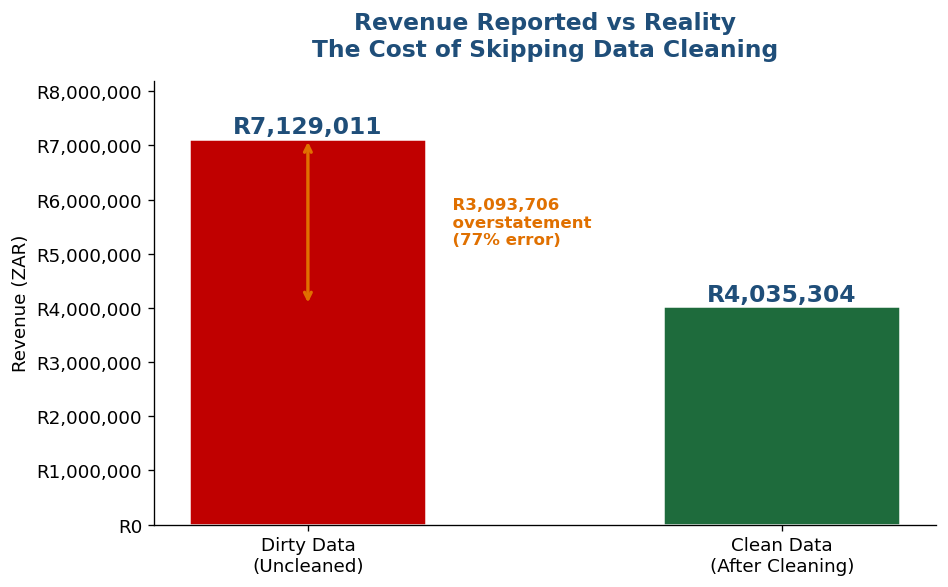

Chart saved


In [45]:
# ── Chart 1: Dirty vs Clean Revenue ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(['Dirty Data\n(Uncleaned)', 'Clean Data\n(After Cleaning)'],
              [dirty_revenue, clean_revenue],
              color=[RED, GREEN], width=0.5, edgecolor='white', linewidth=1.5)

# Value labels
for bar, val in zip(bars, [dirty_revenue, clean_revenue]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'R{val:,.0f}', ha='center', va='bottom', fontsize=14, fontweight='bold',
            color=BLUE)

# Overstatement annotation
ax.annotate('',
    xy=(0, dirty_revenue), xytext=(0, clean_revenue),
    xycoords='data', textcoords='data',
    arrowprops=dict(arrowstyle='<->', color=ORANGE, lw=2))
ax.text(0.28, (dirty_revenue + clean_revenue)/2,
        f'  R{overstatement:,.0f}\n  overstatement\n  ({error_rate:.0f}% error)',
        va='center', color=ORANGE, fontsize=10, fontweight='bold')

ax.set_title('Revenue Reported vs Reality\nThe Cost of Skipping Data Cleaning', 
             fontsize=14, fontweight='bold', color=BLUE, pad=15)
ax.set_ylabel('Revenue (ZAR)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R{x:,.0f}'))
ax.set_ylim(0, dirty_revenue * 1.15)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('chart1_revenue_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

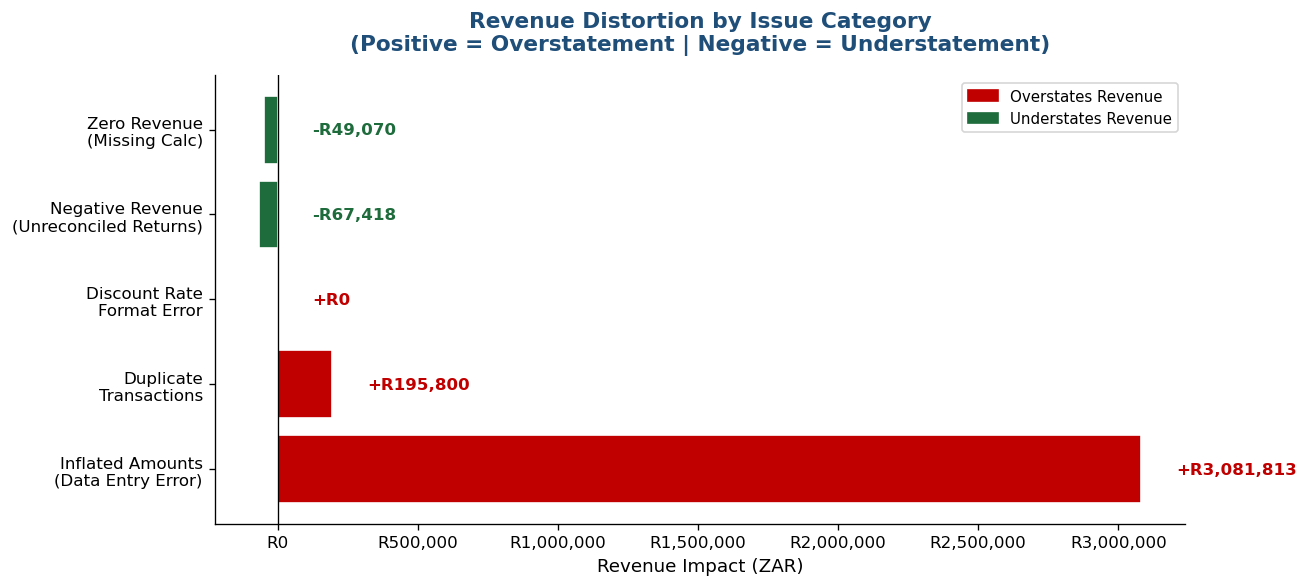

Chart saved


In [46]:
# ── Chart 2: Revenue Impact by Issue Category ───────────────────────────────

MAX_QTY = 5
MAX_UNIT_PRICE_ZAR = 4499.00
BUFFER = 1.05
MAX_LEGITIMATE_REVENUE = MAX_QTY * MAX_UNIT_PRICE_ZAR * BUFFER

df_calc = raw.copy().replace('', float('nan'))
dup_mask_calc = df_calc.duplicated(subset='Transaction_ID', keep='first')
removed_calc = df_calc[dup_mask_calc].copy()
df_calc = df_calc[~dup_mask_calc].copy()

df_calc['Unit_Price_n'] = pd.to_numeric(
    df_calc['Unit_Price'].astype(str).str.replace('R', '', regex=False), errors='coerce')
df_calc['Quantity_n'] = pd.to_numeric(df_calc['Quantity'], errors='coerce')
disc_raw = pd.to_numeric(df_calc['Discount_Rate'], errors='coerce').fillna(0)
disc_fixed = disc_raw.copy()
disc_fixed[disc_fixed > 1] /= 100
df_calc['Rev_expected'] = (
    df_calc['Unit_Price_n'] * df_calc['Quantity_n'] * (1 - disc_fixed)
).round(2)
df_calc['Revenue_n'] = pd.to_numeric(df_calc['Revenue'], errors='coerce')
removed_calc['Revenue_n'] = pd.to_numeric(removed_calc['Revenue'], errors='coerce')

dup_impact      = removed_calc['Revenue_n'].sum()
inf_mask        = df_calc['Revenue_n'] > MAX_LEGITIMATE_REVENUE
inflated_impact = df_calc.loc[inf_mask, 'Revenue_n'].sum() - df_calc.loc[inf_mask, 'Rev_expected'].sum()
disc_err_mask   = disc_raw > 1
disc_impact     = df_calc.loc[disc_err_mask, 'Revenue_n'].sum() - df_calc.loc[disc_err_mask, 'Rev_expected'].sum()
neg_mask        = df_calc['Revenue_n'] < 0
neg_impact      = df_calc.loc[neg_mask, 'Revenue_n'].sum()
zero_mask       = (df_calc['Revenue_n'] == 0) & (df_calc['Quantity_n'] > 0)
zero_impact     = -df_calc.loc[zero_mask, 'Rev_expected'].sum()

issue_impacts = {
    'Inflated Amounts\n(Data Entry Error)':     round(inflated_impact),
    'Duplicate\nTransactions':                  round(dup_impact),
    'Discount Rate\nFormat Error':              round(disc_impact),
    'Negative Revenue\n(Unreconciled Returns)': round(neg_impact),
    'Zero Revenue\n(Missing Calc)':             round(zero_impact),
}

labels = list(issue_impacts.keys())
values = list(issue_impacts.values())
colors = [RED if v > 0 else GREEN for v in values]

# Use the largest absolute value to define a minimum readable offset
max_abs = abs(max(values, key=abs))
MIN_OFFSET = max_abs * 0.04  # 4% of the largest bar — ensures label clears the bar

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels, values, color=colors, edgecolor='white', linewidth=1)

for bar, val in zip(bars, values):
    if val >= 0:
        # Positive bars: label to the right of the bar end
        x_pos = val + MIN_OFFSET
        ha = 'left'
        label_text = f'+R{val:,.0f}'
        font_color = RED
    else:
        # Negative bars: label to the RIGHT of zero (inside the positive space)
        # This avoids overlap with the y-axis labels on the left
        x_pos = MIN_OFFSET
        ha = 'left'
        label_text = f'-R{abs(val):,.0f}'
        font_color = GREEN

    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            label_text,
            va='center', ha=ha, fontsize=10, fontweight='bold',
            color=font_color)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Revenue Distortion by Issue Category\n(Positive = Overstatement | Negative = Understatement)',
             fontsize=13, fontweight='bold', color=BLUE, pad=15)
ax.set_xlabel('Revenue Impact (ZAR)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R{x:,.0f}'))
ax.tick_params(labelsize=10)

red_patch = mpatches.Patch(color=RED, label='Overstates Revenue')
green_patch = mpatches.Patch(color=GREEN, label='Understates Revenue')
ax.legend(handles=[red_patch, green_patch], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_issue_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

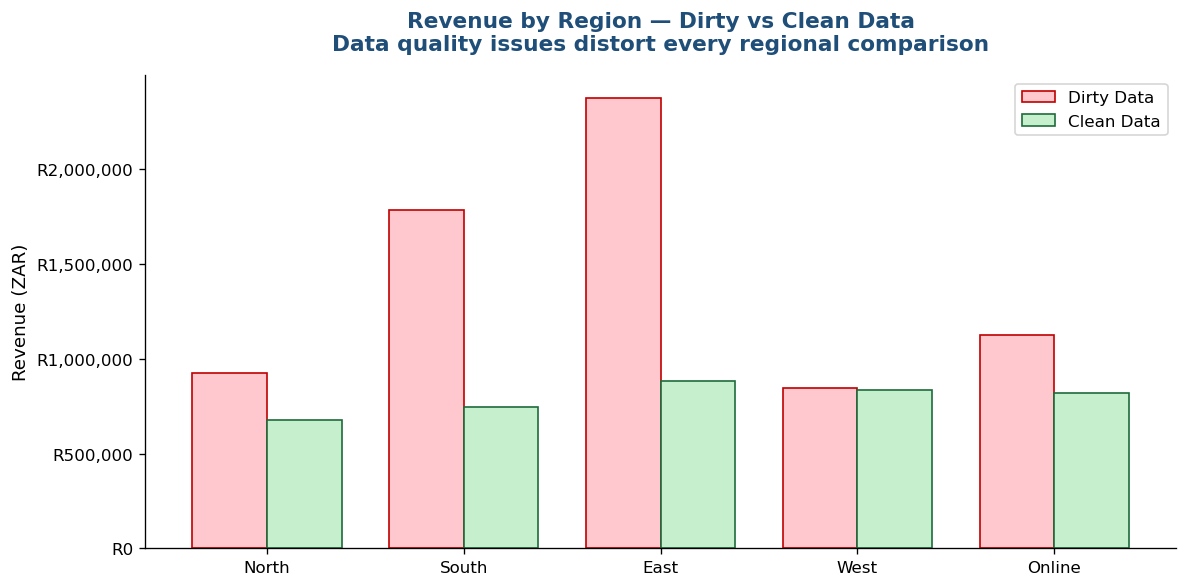

Chart saved


In [47]:
# ── Chart 3: Revenue by Region — Dirty vs Clean ─────────────────────────────

# Dirty — attempt regional aggregation on raw data
raw_copy = raw.copy()
raw_copy['Revenue'] = pd.to_numeric(raw_copy['Revenue'], errors='coerce')
# Standardise region for grouping only
region_map_simple = {'north':'North','NORTH':'North','nrth':'North','n.':'North',
                     'south':'South','SOUTH':'South','sth':'South','s.':'South',
                     'east':'East','EAST':'East','est':'East',
                     'west':'West','WEST':'West','wst':'West',
                     'online':'Online','ONLINE':'Online','on-line':'Online'}
raw_copy['Region_std'] = raw_copy['Region'].apply(lambda x: region_map_simple.get(str(x).lower().strip(), str(x)))
dirty_by_region = raw_copy.groupby('Region_std')['Revenue'].sum()

# Clean
clean_by_region = df_clean[df_clean['Region'].isin(['North','South','East','West','Online'])].groupby('Region')['Revenue'].sum()

regions_ordered = ['North', 'South', 'East', 'West', 'Online']
x = np.arange(len(regions_ordered))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [dirty_by_region.get(r, 0) for r in regions_ordered], width, label='Dirty Data', color=LIGHT_RED, edgecolor=RED, linewidth=1)
ax.bar(x + width/2, [clean_by_region.get(r, 0) for r in regions_ordered], width, label='Clean Data', color=LIGHT_GREEN, edgecolor=GREEN, linewidth=1)

ax.set_title('Revenue by Region — Dirty vs Clean Data\nData quality issues distort every regional comparison',
             fontsize=13, fontweight='bold', color=BLUE, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(regions_ordered, fontsize=11)
ax.set_ylabel('Revenue (ZAR)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R{x:,.0f}'))
ax.legend(fontsize=10)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('chart3_region_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

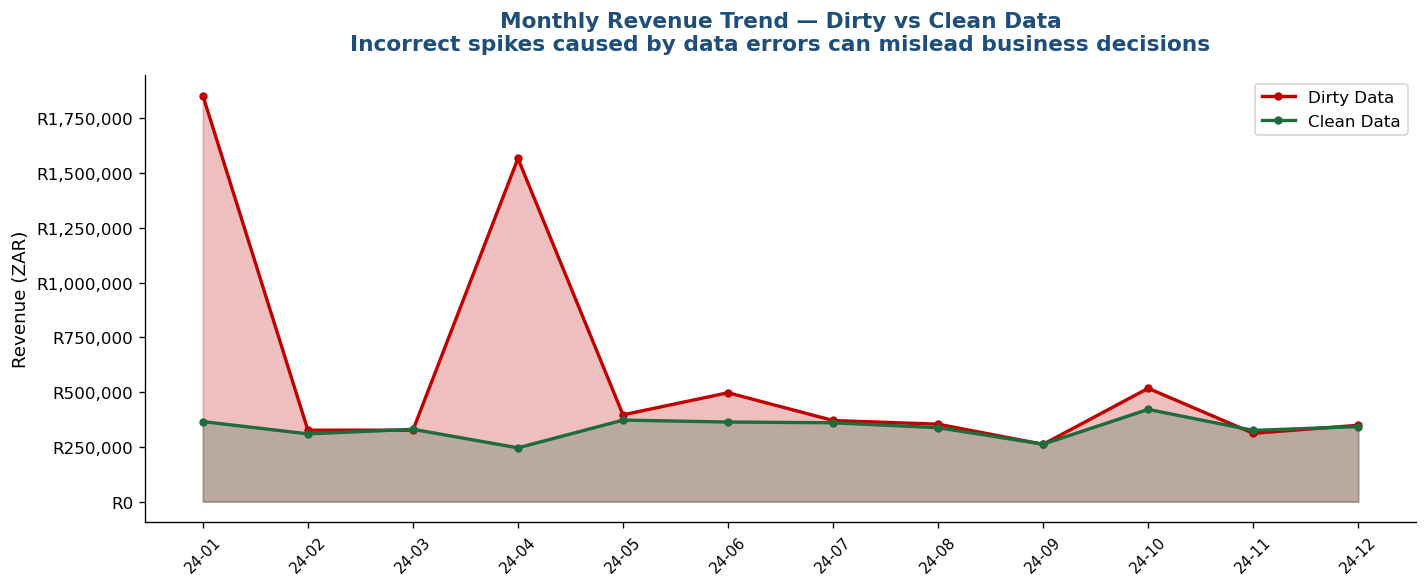

Chart saved


In [48]:
# ── Chart 4: Monthly Revenue Trend — Dirty vs Clean ─────────────────────────

raw_copy['Date_parsed'] = pd.to_datetime(raw_copy['Date'].apply(
    lambda x: parse_date(x) if pd.notna(x) else np.nan), errors='coerce')
raw_copy['Month'] = raw_copy['Date_parsed'].dt.to_period('M')
dirty_monthly = raw_copy.groupby('Month')['Revenue'].sum().sort_index()

df_clean['Month'] = pd.to_datetime(df_clean['Date'], errors='coerce').dt.to_period('M')
clean_monthly = df_clean.groupby('Month')['Revenue'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(len(dirty_monthly)), dirty_monthly.values, alpha=0.25, color=RED)
ax.plot(range(len(dirty_monthly)), dirty_monthly.values, color=RED, linewidth=2, label='Dirty Data', marker='o', markersize=4)
ax.fill_between(range(len(clean_monthly)), clean_monthly.values, alpha=0.25, color=GREEN)
ax.plot(range(len(clean_monthly)), clean_monthly.values, color=GREEN, linewidth=2, label='Clean Data', marker='o', markersize=4)

months = [str(m) for m in dirty_monthly.index]
ax.set_xticks(range(len(months)))
ax.set_xticklabels([m[-5:] for m in months], rotation=45, fontsize=9)
ax.set_title('Monthly Revenue Trend — Dirty vs Clean Data\nIncorrect spikes caused by data errors can mislead business decisions',
             fontsize=13, fontweight='bold', color=BLUE, pad=15)
ax.set_ylabel('Revenue (ZAR)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R{x:,.0f}'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

<a id="6"></a>
## 6. Conclusion & Business Implications

---

### What we found

| Metric | Dirty Data | Clean Data |
|---|---|---|
| Total Transactions | 1,050 | 1,000 |
| Reported Revenue | R7,129,010.66 | R4,035,304.33 |
| Revenue Error | — | **R3,093,706.33 (76.7%)** |

### Why this matters beyond the number

The R3,093,706.33 overstatement is striking, but the downstream consequences are often worse:

- **Commission calculations** based on dirty revenue will overpay or underpay sales teams
- **Inventory planning** driven by inflated demand signals will lead to overstock and cash flow issues  
- **Regional reporting** is meaningless when region names are inconsistent across 5 formats
- **Tax reporting** on incorrect revenue figures creates compliance risk
- **Executive dashboards** built on unclean data create false confidence and poor strategic decisions

### The fix is not complicated — but it must be systematic

The 7 cleaning steps in this notebook took under 2 minutes to execute on 1,000 rows. The real challenge is building these checks into a **repeatable pipeline** so every data load is validated automatically — before it ever reaches a report.

---

*This analysis was produced using Python (pandas, matplotlib) on a realistic synthetic dataset designed to reflect common data quality issues in retail / e-commerce transaction systems.*

In [49]:
# Export the clean dataset
df_clean.to_csv('retail_cleaned_data.csv', index=False)
print(f'Clean dataset exported: {len(df_clean):,} rows')
print(f'Verified revenue total: R{df_clean["Revenue"].sum():,.2f}')

Clean dataset exported: 1,000 rows
Verified revenue total: R4,035,304.33
